####Importing the essential libraries for data analysis and visualization:

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

####Installing/updating the AutoGluon Tabular library for automated machine learning.


In [29]:
!pip -q install -U autogluon.tabular

#####Importing the tools required for modeling, data splitting, and evaluation metrics

In [30]:
from autogluon.tabular import TabularPredictor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

##### Loading the training, testing, and sample submission datasets, then displaying their shapes and previewing the data



In [31]:

train_df = pd.read_csv("train.csv", index_col=0)
test_df = pd.read_csv("test.csv", index_col=0)
sample_sub = pd.read_csv("sample_submission.csv")

print(train_df.shape)
print(test_df.shape)

train_df.head()

(188533, 12)
(125690, 11)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
id,,,,,,,,,,,,
0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


In [32]:
train_df

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
id,,,,,,,,,,,,
0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500
...,...,...,...,...,...,...,...,...,...,...,...,...
188528,Cadillac,Escalade ESV Platinum,2017,49000,Gasoline,420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,White,Beige,None reported,Yes,27500
188529,Mercedes-Benz,AMG C 43 AMG C 43 4MATIC,2018,28600,Gasoline,385.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,8-Speed A/T,White,Black,At least 1 accident or damage reported,Yes,30000
188530,Mercedes-Benz,AMG GLC 63 Base 4MATIC,2021,13650,Gasoline,469.0HP 4.0L 8 Cylinder Engine Gasoline Fuel,7-Speed A/T,White,Black,None reported,Yes,86900


###### Showing dataset information including column names, data types, and missing values

In [33]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 188533 entries, 0 to 188532
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   brand         188533 non-null  object
 1   model         188533 non-null  object
 2   model_year    188533 non-null  int64 
 3   milage        188533 non-null  int64 
 4   fuel_type     183450 non-null  object
 5   engine        188533 non-null  object
 6   transmission  188533 non-null  object
 7   ext_col       188533 non-null  object
 8   int_col       188533 non-null  object
 9   accident      186081 non-null  object
 10  clean_title   167114 non-null  object
 11  price         188533 non-null  int64 
dtypes: int64(3), object(9)
memory usage: 18.7+ MB


In [34]:
train_df.isnull().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,5083
engine,0
transmission,0
ext_col,0
int_col,0
accident,2452


In [35]:
train_df.shape

(188533, 12)

In [36]:
missing_value = train_df.isnull().sum()
missing_value[missing_value > 0]

,0
fuel_type,5083
accident,2452
clean_title,21419


#####Visualizing the distribution of the target variable (price) to understand skewness and outliers.

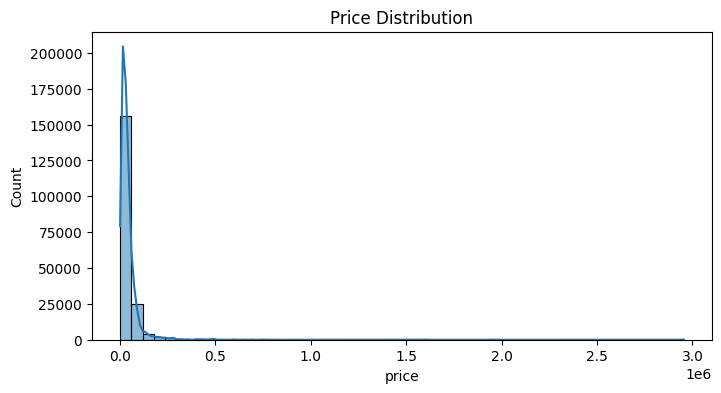

In [37]:
plt.figure(figsize=(8, 4))
sns.histplot(train_df["price"], bins=50, kde=True)
plt.title("Price Distribution")
plt.xlabel("price")
plt.ylabel("Count")
plt.show()

####Separating numerical and categorical columns

In [38]:
num_col = train_df.select_dtypes(include=np.number).columns
cat_col = train_df.select_dtypes(exclude=np.number).columns
num_col, cat_col

(Index(['model_year', 'milage', 'price'], dtype='object'),
 Index(['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col',
        'int_col', 'accident', 'clean_title'],
       dtype='object'))

####Plotting histograms for all numerical features to analyze their distributions

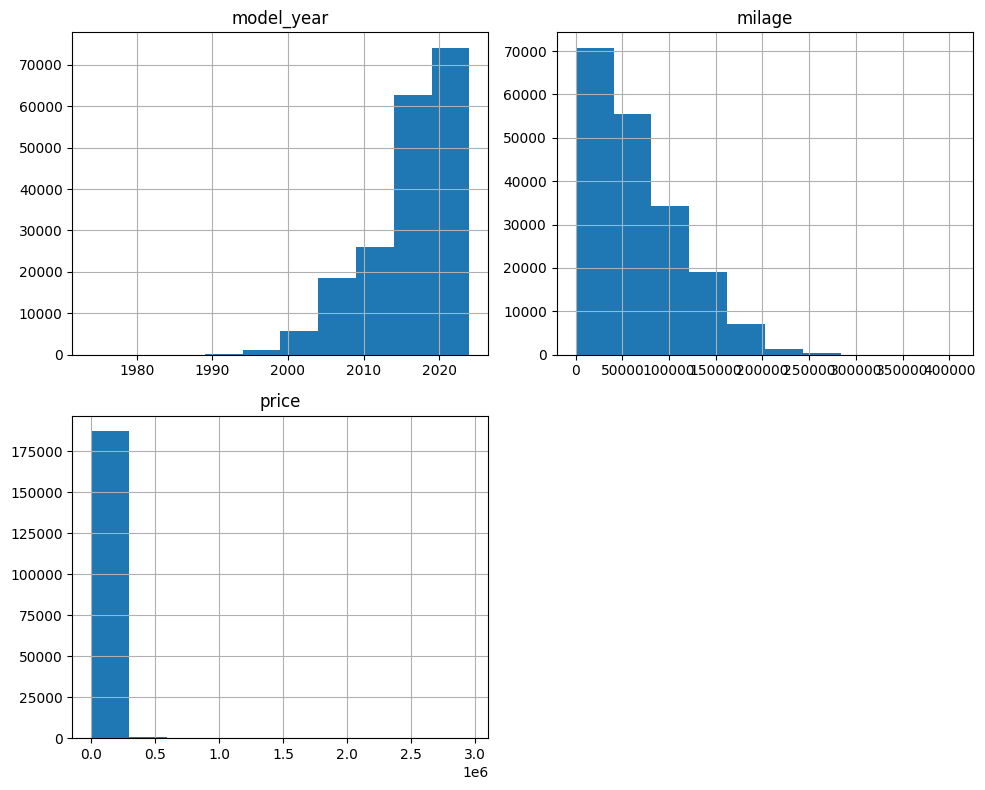

In [39]:
train_df[num_col].hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

####Computing and visualizing the correlation matrix for numerical features

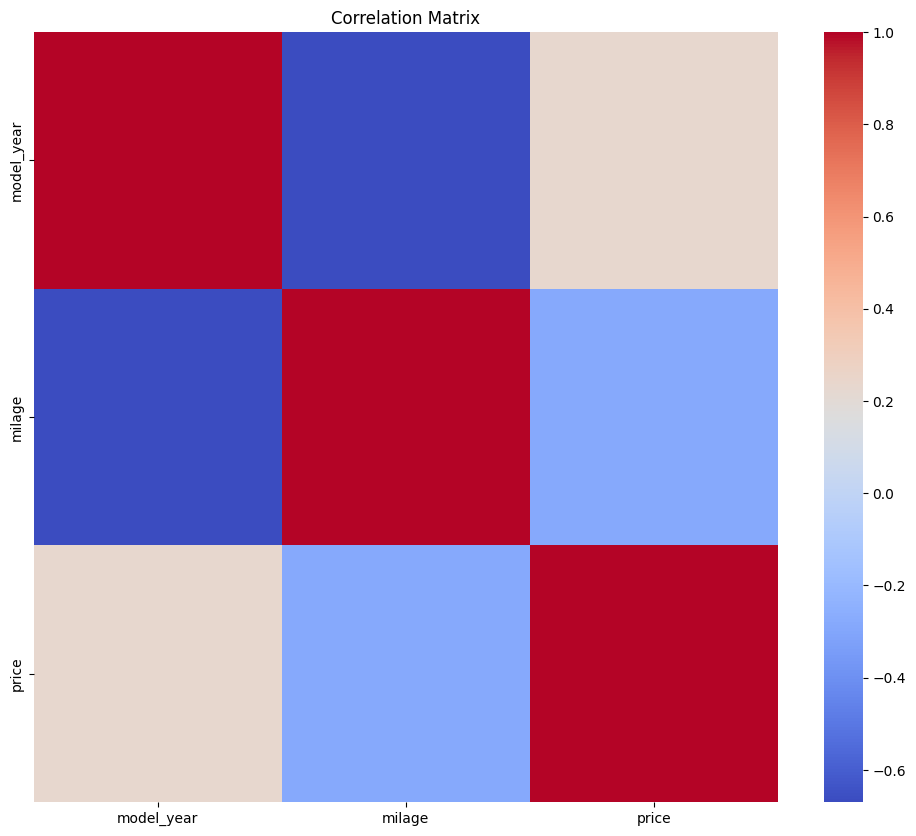

In [40]:
corr_matrix = train_df[num_col].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

####Defining a helper function to clean string columns and replace missing values with "Missing"

In [41]:
def clean_str(s):
    return s.fillna("Missing").astype(str).str.strip()

####Defining a safe division function to avoid division by zero and missing values

In [42]:
def safe_div(a, b):
    return np.where((b == 0) | pd.isna(b), np.nan, a / b)

####Defining helper functions for mileage extraction, engine detection, and luxury brand identification

In [43]:
def get_mileage_column(df):
    if "milage" in df.columns:
        return "milage"
    if "mileage" in df.columns:
        return "mileage"
    raise KeyError("Neither 'milage' nor 'mileage' found in dataframe.")

LUXURY_BRANDS = [
    "mercedes", "bmw", "audi", "lexus", "porsche", "land rover",
    "jaguar", "bentley", "maserati", "rolls-royce", "ferrari",
    "lamborghini", "aston martin", "mclaren", "infiniti", "acura",
    "cadillac", "lincoln"
]

####Defining a function to determine whether a car brand is considered luxury

In [44]:
def is_luxury_brand(x):
    x = str(x).lower()
    return int(any(b in x for b in LUXURY_BRANDS))

####Defining a function to simplify transmission types into grouped categories

In [45]:
def transmission_simple(x):
    x = str(x).lower()
    if "auto" in x or "cvt" in x or "dual" in x or "dct" in x:
        return "A/T"
    if "manual" in x or "m/t" in x:
        return "M/T"
    return "Other"

####Defining a function to extract engine-related features such as horsepower, engine size, cylinder count, turbo, hybrid, and electric indicators

In [46]:
def parse_engine_features(eng_series):
    eng = eng_series.fillna("").astype(str).str.lower()

    hp = pd.to_numeric(
        eng.str.extract(r"([\d.]+)\s*(?:hp|bhp|horsepower)", expand=False),
        errors="coerce"
    )

    engine_size_l = pd.to_numeric(
        eng.str.extract(r"([\d.]+)\s*l\b", expand=False),
        errors="coerce"
    )

    cyl1 = eng.str.extract(r"(\d+)\s*(?:cyl|cylinder)", expand=False)
    cyl2 = eng.str.extract(r"[vvi](\d+)", expand=False)
    cylinders = pd.to_numeric(cyl1.fillna(cyl2), errors="coerce")

    has_turbo = eng.str.contains(r"turbo|supercharged|charged", regex=True, na=False).astype(int)
    is_electric = eng.str.contains(r"electric|ev", regex=True, na=False).astype(int)
    is_hybrid = eng.str.contains(r"hybrid", regex=True, na=False).astype(int)

    return hp, engine_size_l, cylinders, has_turbo, is_electric, is_hybrid

####Defining the add_features function to create engineered features such as car age, log mileage, engine features, transmission type, and interaction features

In [47]:
def add_features(df, ref_year):
    df = df.copy()

    for c in ["brand", "model", "fuel_type", "transmission", "engine", "ext_col", "int_col", "accident", "clean_title"]:
        if c in df.columns:
            df[c] = clean_str(df[c])

    if "model_year" in df.columns:
        df["model_year"] = pd.to_numeric(df["model_year"], errors="coerce")
    else:
        df["model_year"] = np.nan

    mileage_col = get_mileage_column(df)
    df[mileage_col] = pd.to_numeric(df[mileage_col], errors="coerce")

    df["car_age"] = (ref_year - df["model_year"]).clip(lower=0)
    df["log_milage"] = np.log1p(df[mileage_col].clip(lower=0))
    df["mileage_per_year"] = safe_div(df[mileage_col], df["car_age"].replace(0, 0.5))

    hp, engine_size_l, cylinders, has_turbo, is_electric, is_hybrid = parse_engine_features(df["engine"])
    df["hp"] = hp
    df["engine_size_l"] = engine_size_l
    df["cylinders"] = cylinders
    df["hp_per_l"] = safe_div(df["hp"], df["engine_size_l"])
    df["has_turbo"] = has_turbo
    df["is_electric"] = is_electric
    df["is_hybrid"] = is_hybrid

    tr = df["transmission"].fillna("").astype(str).str.lower()
    df["trans_speed"] = pd.to_numeric(tr.str.extract(r"(\d+)[- ]?speed", expand=False), errors="coerce")
    df["is_auto"] = tr.str.contains(r"a/t|automatic|cvt|dual[\s-]?clutch", regex=True, na=False).astype(int)
    df["is_manual"] = tr.str.contains(r"m/t|manual", regex=True, na=False).astype(int)
    df["transmission_simple"] = df["transmission"].apply(transmission_simple)

    if "brand" in df.columns:
        df["is_luxury"] = df["brand"].apply(is_luxury_brand).astype(int)
    else:
        df["is_luxury"] = 0

    if "brand" in df.columns and "model" in df.columns:
        df["brand_model"] = df["brand"].astype(str) + "_" + df["model"].astype(str)
    else:
        df["brand_model"] = "Missing_Missing"

    if "ext_col" in df.columns and "int_col" in df.columns:
        df["int_ext_col"] = df["int_col"].astype(str) + "_" + df["ext_col"].astype(str)
        df["brand_int_col"] = df["brand"].astype(str) + "_" + df["int_col"].astype(str)
        df["brand_ext_col"] = df["brand"].astype(str) + "_" + df["ext_col"].astype(str)
    else:
        df["int_ext_col"] = "Missing_Missing"
        df["brand_int_col"] = "Missing_Missing"
        df["brand_ext_col"] = "Missing_Missing"

    if "fuel_type" in df.columns:
        df["fuel_simple"] = df["fuel_type"].replace({
            "Premium Gasoline": "Gasoline",
            "Regular Unleaded": "Gasoline",
            "Flex Fuel": "Other",
            "not supported": "Missing",
            "–": "Missing",
        })
    else:
        df["fuel_simple"] = "Missing"

    return df

####Defining a function to group rare categorical values into a single __RARE__ category

In [50]:

def rare_group(train, test, col, min_count=20):
    if col not in train.columns or col not in test.columns:
        return
    vc = train[col].astype(str).value_counts()
    keep = set(vc[vc >= min_count].index)
    train[col] = train[col].astype(str).where(train[col].astype(str).isin(keep), "__RARE__")
    test[col] = test[col].astype(str).where(test[col].astype(str).isin(keep), "__RARE__")

####Setting a reference year and applying feature engineering to both training and testing datasets

In [51]:
ref_year = int(pd.to_numeric(train_df["model_year"], errors="coerce").max()) + 1

train_df = add_features(train_df, ref_year)
test_df = add_features(test_df, ref_year)


####Grouping rare categories for important categorical columns such as model, brand_model, and color-related features

In [52]:
for c in ["model", "brand_model", "ext_col", "int_col", "int_ext_col", "brand_int_col", "brand_ext_col"]:
    rare_group(train_df, test_df, c, min_count=20)

####Ensuring that the target column price exists and defining it as the prediction target

In [53]:
assert "price" in train_df.columns
label = "price"

####Dropping the id column and separating features from the target variable

In [54]:
train_df = train_df.drop("id", axis=1, errors="ignore")

x = train_df.drop("price", axis=1)
y = train_df["price"]

x.shape, y.shape

((188533, 26), (188533,))

####Splitting the dataset into training and validation sets using a 90/10 ratio

In [55]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.1,
    random_state=42
)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((169679, 26), (18854, 26), (169679,), (18854,))

####Combining features and targets into training and validation DataFrames

In [56]:
train_data = x_train.copy()
train_data["price"] = y_train

val_data = x_test.copy()
val_data["price"] = y_test

train_data.shape, val_data.shape

((169679, 27), (18854, 27))

In [57]:
!pip install catboost

####Creating and training the AutoGluon regression model with advanced settings such as bagging and stacking

In [58]:
predictor = TabularPredictor(
    label=label,
    problem_type="regression",
    eval_metric="root_mean_squared_error",
    path="ag_models_v3"
)

predictor.fit(
    train_data=train_df,
    presets="best_quality",
    time_limit=2 * 60 * 60,
    num_bag_folds=5,
    num_stack_levels=2,
    refit_full=True,
    verbosity=2
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.11.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       8.47 GB / 12.67 GB (66.9%)
Disk Space Avail:   86.44 GB / 107.72 GB (80.2%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=2, num_bag_folds=5, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` va

####Displaying the leaderboard of trained models to compare their performance

In [59]:
lb = predictor.leaderboard(silent=True)
print(lb.head(20))


                          model     score_val              eval_metric  \
0           WeightedEnsemble_L4 -72612.882565  root_mean_squared_error   
1           WeightedEnsemble_L2 -72661.017083  root_mean_squared_error   
2           WeightedEnsemble_L3 -72733.653089  root_mean_squared_error   
3               CatBoost_BAG_L1 -72738.123670  root_mean_squared_error   
4             LightGBMXT_BAG_L2 -72786.217302  root_mean_squared_error   
5             LightGBMXT_BAG_L3 -72894.410092  root_mean_squared_error   
6             LightGBMXT_BAG_L1 -72926.627955  root_mean_squared_error   
7               LightGBM_BAG_L2 -73057.213625  root_mean_squared_error   
8               LightGBM_BAG_L1 -73252.586856  root_mean_squared_error   
9               LightGBM_BAG_L3 -73256.987307  root_mean_squared_error   
10       RandomForestMSE_BAG_L2 -74958.928074  root_mean_squared_error   
11         LightGBMLarge_BAG_L1 -75051.660791  root_mean_squared_error   
12       RandomForestMSE_BAG_L3 -75716

####Evaluating the model on the validation set using RMSE

In [71]:
x_train_raw, x_test_raw, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.1,
    random_state=42
)

ref_year = int(pd.to_numeric(x_train_raw["model_year"], errors="coerce").max()) + 1

x_train_fe = add_features(x_train_raw, ref_year)
x_test_fe = add_features(x_test_raw, ref_year)

train_data = x_train_fe.copy()
train_data["price"] = y_train.values

val_data = x_test_fe.copy()
val_data["price"] = y_test.values

required_cols = [
    "transmission_simple", "is_luxury",
    "int_ext_col", "brand_int_col", "brand_ext_col"
]


y_pred = predictor.predict(val_data.drop(columns=["price"]))

rmse = np.sqrt(mean_squared_error(val_data["price"], y_pred))
print("Validation RMSE:", rmse)

Missing in val_data: []
Missing in train_data: []
Validation RMSE: 65799.05409654458


####Checking whether important engineered features exist in the validation dataset

In [72]:
required_cols = [
    "transmission_simple",
    "is_luxury",
    "int_ext_col",
    "brand_int_col",
    "brand_ext_col"
]

print([c for c in required_cols if c not in val_data.columns])

[]


####Generating predictions on the test dataset and preparing the final submission file

In [73]:
test_pred = predictor.predict(test_df)

submission = sample_sub.copy()
if "price" in submission.columns:
    submission["price"] = np.clip(test_pred.to_numpy(), 0, None)
else:
    pred_col = [c for c in submission.columns if c != submission.columns[0]][0]
    submission[pred_col] = np.clip(test_pred.to_numpy(), 0, None)

submission.to_csv("submission.csv", index=False)

print("Saved:", "submission.csv")
print(submission.head())

Saved: submission.csv
       id         price
0  188533  17454.509766
1  188534  80174.492188
2  188535  55017.679688
3  188536  28973.521484
4  188537  29782.613281


In [74]:
submission.to_csv("submission.csv", index=False)
print("submission.csv saved successfully")

submission.csv saved successfully
